<a href="https://colab.research.google.com/github/vivek143pro/NorthStar-Analytics-Vivek/blob/main/NOTEBOOK_1%20-%20SQL%20in%20R%20%2B%20R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NorthStar Urban Mobility and Logistics
Name:Vivek gubbala 33126816 Module: Databases and Analytics

In [1]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Changed lab environment to R after importing by python

In [8]:
install.packages(c("sqldf", "ggplot2", "dplyr"), repos="https://cran.r-project.org", quiet=TRUE)
library(sqldf)
library(ggplot2)
library(dplyr)
cat("Packages ready\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Packages ready


NorthStar's data is spread across 9 operational tables covering orders, deliveries,
customers, drivers, vehicles, hubs, incidents, complaints, and app events.

In [1]:
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
customers  <- read.csv("customers.csv")
drivers    <- read.csv("drivers.csv")
vehicles   <- read.csv("vehicles.csv")
hubs       <- read.csv("hubs.csv")
incidents  <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")

cat("orders:", nrow(orders), "rows\n")
cat("deliveries:", nrow(deliveries), "rows\n")
cat("complaints:", nrow(complaints), "rows\n")

orders: 1250 rows
deliveries: 950 rows
complaints: 320 rows


# Before any analysis, the data must be cleaned. Key issues identified:

| Dataset | Issue | Action |
|---------|-------|--------|
| deliveries | 14 missing customer ratings | Left as NA — unrated journeys |
| customers | 20 missing loyalty scores | Left as NA — incomplete profiles |
| incidents | 17 missing resolved_hours | Indicates unresolved incidents |
| complaints | 16 missing compensation amounts | Complaints closed without payout |
| all zones | Inconsistent casing + "Ctr" dirty value | Standardised to Title Case, "Ctr" → "Central" |
| orders | Dates stored as Unix timestamps | Converted using origin="1970-01-01" |
| deliveries | Dates with fractional seconds | Parsed using %OS format |

These issues are evidence of NorthStar's fragmented data systems — different
teams recording data differently with no central standard enforced.

In [10]:
# CELL 3 — Data Cleaning
#1. Check missing values
cat("=== MISSING VALUES ===\n")
for (name in c("orders","deliveries","customers","drivers","vehicles","hubs","incidents","complaints")) {
  df <- get(name)
  missing_counts <- colSums(is.na(df))
  missing_counts <- missing_counts[missing_counts > 0]
  cat("\n", name, ":\n")
  if (length(missing_counts) > 0) {
    print(missing_counts)
  } else {
    cat("  No missing values\n")
  }
}

#2. Standardise zone name casing
orders$pickup_zone     <- trimws(tools::toTitleCase(tolower(orders$pickup_zone)))
orders$dropoff_zone    <- trimws(tools::toTitleCase(tolower(orders$dropoff_zone)))
customers$home_zone    <- trimws(tools::toTitleCase(tolower(customers$home_zone)))
drivers$base_zone      <- trimws(tools::toTitleCase(tolower(drivers$base_zone)))
vehicles$assigned_zone <- trimws(tools::toTitleCase(tolower(vehicles$assigned_zone)))

# Fix dirty zone value
orders$pickup_zone[orders$pickup_zone == "Ctr"]         <- "Central"
orders$dropoff_zone[orders$dropoff_zone == "Ctr"]       <- "Central"
customers$home_zone[customers$home_zone == "Ctr"]       <- "Central"
drivers$base_zone[drivers$base_zone == "Ctr"]           <- "Central"
vehicles$assigned_zone[vehicles$assigned_zone == "Ctr"] <- "Central"

cat("\nZone values after cleaning:\n")
print(unique(orders$pickup_zone))

#3. Standardise categorical columns
deliveries$delivery_status  <- trimws(deliveries$delivery_status)
complaints$status           <- trimws(complaints$status)
complaints$severity         <- trimws(complaints$severity)
vehicles$maintenance_status <- trimws(vehicles$maintenance_status)

#4. Parse date columns
cat("\nSample date from orders:", orders$order_created_at[1], "\n")
cat("Sample date from deliveries:", deliveries$delivery_completed_at[1], "\n")

# Orders dates are Unix timestamps (numbers)
orders$order_created_at <- as.POSIXct(
  as.numeric(orders$order_created_at), origin="1970-01-01", tz="UTC"
)

# Delivery dates are standard format with fractional seconds
deliveries$dispatch_time         <- as.POSIXct(deliveries$dispatch_time,         format="%Y-%m-%d %H:%M:%OS")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%OS")
complaints$created_at            <- as.POSIXct(complaints$created_at,            format="%Y-%m-%d %H:%M:%S")

cat("Parsed order date:", format(orders$order_created_at[1]), "\n")
cat("Parsed delivery date:", format(deliveries$delivery_completed_at[1]), "\n")

#5. Calculate delivery duration
deliveries$duration_hrs <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units="hours")
)

#6. Flag data errors
bad_rows <- sum(deliveries$duration_hrs < 0, na.rm=TRUE)
cat("\nDeliveries with negative duration (data error):", bad_rows, "\n")

#7. Check duplicate IDs
cat("Duplicate order IDs:", sum(duplicated(orders$order_id)), "\n")
cat("Duplicate delivery IDs:", sum(duplicated(deliveries$delivery_id)), "\n")

cat("\nData cleaning complete\n")

=== MISSING VALUES ===

 orders :
order_created_at 
            1250 

 deliveries :
        delivery_completed_at customer_rating_post_delivery 
                           19                            14 
                 duration_hrs 
                           19 

 customers :
loyalty_score 
           20 

 drivers :
training_score 
             7 

 vehicles :
battery_health_pct 
                 4 

 hubs :
  No missing values

 incidents :
resolved_hours 
            17 

 complaints :
compensation_amount 
                 16 

Zone values after cleaning:
[1] "Airport"   "North"     "West"      "Riverside" "Central"   "South"    
[7] "East"     

Sample date from orders: NA 
Sample date from deliveries: 1718787960 
Parsed order date: NA 
Parsed delivery date: 2024-06-19 09:05:59 

Deliveries with negative duration (data error): 64 
Duplicate order IDs: 0 
Duplicate delivery IDs: 0 

Data cleaning complete


##Feature Engineering in R

Feature engineering is the process of creating new meaningful variables
from existing raw columns. Raw data alone often cannot reveal operational
patterns — engineered features transform it into analytically useful variables
that power the SQL queries and visualisations in subsequent steps.

Feature engineering is performed here in R to demonstrate the process
independently from the Python implementation in Notebook 2. Both notebooks
engineer the same core features using different language syntax, and both
produce identical results — confirming consistency across tools.

### Features Created in This Step

| Feature | Source Columns | Purpose |
|---------|---------------|---------|
| duration_hrs | dispatch_time, delivery_completed_at | Actual delivery time in hours |
| is_failed | delivery_status | Binary flag — 1 if Failed, 0 otherwise |
| is_delayed | delivery_status | Binary flag — 1 if Delayed, 0 otherwise |
| is_ontime | delivery_status | Binary flag — 1 if OnTime, 0 otherwise |
| high_override | manual_route_override_count | Flags deliveries with more than 1 override |
| peak_hour | dispatch_time | Flags dispatches during 7-9am or 5-7pm |
| margin | order_value, fuel_or_charge_cost | Gross profit per delivery in £ |
| value_band | order_value | Groups orders into 5 price brackets |
| risk_score | multiple columns | Composite operational risk score per delivery |

### Risk Score Design

The composite risk score assigns weighted points based on known failure indicators:

| Risk Factor | Points | Rationale |
|-------------|--------|-----------|
| Proof of completion missing | +3 | Strongest single predictor of failed deliveries |
| Vehicle in InRepair status | +3 | Vehicle should not be dispatched |
| Manual route overrides > 1 | +2 | Multiple deviations indicate route or driver issue |
| Critical priority order | +1 | Higher expectation increases complaint risk if late |

A higher score means a higher risk of failure. The model is validated by
checking whether failed deliveries actually score higher than on-time ones.

In [14]:
# CELL 3C — Feature Engineering in R
# --- 1. Delivery duration in hours ---
deliveries$duration_hrs <- as.numeric(
  difftime(deliveries$delivery_completed_at,
           deliveries$dispatch_time, units="hours")
)
cat("Duration stats:\n")
print(summary(deliveries$duration_hrs))

# Flag negative durations as data errors
negative_durations <- sum(deliveries$duration_hrs < 0, na.rm=TRUE)
cat("Negative durations (data errors):", negative_durations, "\n")

# --- 2. Binary outcome flags ---
deliveries$is_failed  <- as.integer(deliveries$delivery_status == "Failed")
deliveries$is_delayed <- as.integer(deliveries$delivery_status == "Delayed")
deliveries$is_ontime  <- as.integer(deliveries$delivery_status == "OnTime")

cat("\nOutcome flags:\n")
cat("Failed:", sum(deliveries$is_failed), "\n")
cat("Delayed:", sum(deliveries$is_delayed), "\n")
cat("OnTime:", sum(deliveries$is_ontime), "\n")

# --- 3. High override flag ---
deliveries$high_override <- as.integer(
  deliveries$manual_route_override_count > 1
)
cat("\nHigh override deliveries (>1):", sum(deliveries$high_override), "\n")

# --- 4. Peak hour flag ---
deliveries$dispatch_hour <- as.integer(
  format(deliveries$dispatch_time, "%H")
)
deliveries$peak_hour <- as.integer(
  (deliveries$dispatch_hour >= 7 & deliveries$dispatch_hour <= 9) |
  (deliveries$dispatch_hour >= 17 & deliveries$dispatch_hour <= 19)
)
cat("Peak hour dispatches:", sum(deliveries$peak_hour, na.rm=TRUE), "\n")

# --- 5. Gross margin ---
# Join order value to deliveries first
merged <- merge(deliveries, orders[, c("order_id","order_value","priority_level","service_type")],
                by="order_id", all.x=TRUE)
merged$margin <- merged$order_value - merged$fuel_or_charge_cost

cat("\nMargin summary:\n")
print(summary(merged$margin))
cat("Loss-making deliveries:", sum(merged$margin < 0, na.rm=TRUE), "\n")

# --- 6. Order value bands ---
orders$value_band <- cut(
  orders$order_value,
  breaks=c(0, 50, 100, 150, 200, Inf),
  labels=c("Low (0-50)", "Medium (50-100)", "High (100-150)",
           "Premium (150-200)", "Elite (200+)"),
  include.lowest=TRUE
)
cat("\nOrder value band distribution:\n")
print(table(orders$value_band))

# --- 7. Composite risk score ---
merged2 <- merge(merged,
                 vehicles[, c("vehicle_id", "maintenance_status")],
                 by="vehicle_id", all.x=TRUE)

cat("Merged2 rows:", nrow(merged2), "\n")

# Now build risk score
merged2$risk_score <- (
  as.integer(merged2$manual_route_override_count > 1) * 2 +
  as.integer(merged2$proof_of_completion_missing == 1) * 3 +
  as.integer(merged2$maintenance_status == "InRepair") * 3 +
  as.integer(merged2$priority_level == "Critical") * 1
)

cat("\nRisk score distribution:\n")
print(table(merged2$risk_score))

cat("\nAvg risk score by delivery status:\n")
print(tapply(merged2$risk_score, merged2$delivery_status, mean, na.rm=TRUE))

cat("\nFeature engineering complete\n")

Duration stats:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -2.214   2.946   7.074   9.545  14.644  43.457      19 
Negative durations (data errors): 64 

Outcome flags:
Failed: 132 
Delayed: 202 
OnTime: 616 

High override deliveries (>1): 241 
Peak hour dispatches: 242 

Margin summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -9.42   36.08   64.11   79.02  109.73  489.52 
Loss-making deliveries: 23 

Order value band distribution:

       Low (0-50)   Medium (50-100)    High (100-150) Premium (150-200) 
              331               488               230               124 
     Elite (200+) 
               77 
Merged2 rows: 950 

Risk score distribution:

  0   1   2   3   4   5   6   7   8 
440  41 159 209  14  58  18   3   8 

Avg risk score by delivery status:
 Delayed   Failed   OnTime 
2.079208 2.848485 1.183442 

Feature engineering complete


# Statistical Analysis

Before running SQL queries we perform statistical analysis to understand
the shape and distribution of the data. This helps identify whether
patterns we find later are statistically meaningful or just noise.

Key tests:
- Summary statistics across key operational fields
- Correlation between route overrides and customer satisfaction
- Breakdown of delivery outcomes to understand baseline performance

In [15]:
# Summary statistics
cat("=== Delivery Status Breakdown ===\n")
print(table(deliveries$delivery_status))

cat("\n=== Order Value Summary by Service Type ===\n")
print(tapply(orders$order_value, orders$service_type, summary))

# Correlation between overrides and customer rating
cat("\n=== Correlation: Overrides vs Customer Rating ===\n")
cor_test <- cor.test(deliveries$manual_route_override_count,
                      deliveries$customer_rating_post_delivery,
                      use = "complete.obs")
print(cor_test)
cat("Interpretation: correlation =", round(cor_test$estimate, 3), "\n")
cat("A negative value means more overrides = lower customer satisfaction\n")

=== Delivery Status Breakdown ===

Delayed  Failed  OnTime 
    202     132     616 

=== Order Value Summary by Service Type ===
$Business
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6.28   50.49   79.83   92.25  118.24  321.68 

$Medical
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   45.00   71.30   87.14  124.55  292.33 

$Parcel
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.57   47.21   73.56   87.62  115.47  510.06 

$Passenger
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5.92   51.75   81.91   96.07  126.65  326.38 

$Retail
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   4.22   43.73   75.21   90.01  122.59  355.62 


=== Correlation: Overrides vs Customer Rating ===

	Pearson's product-moment correlation

data:  deliveries$manual_route_override_count and deliveries$customer_rating_post_delivery
t = -1.834, df = 934, p-value = 0.06697
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.123507286  0

### Query 1 — Delivery Failure Rate by Zone
**Business question:** Which zones consistently underperform?

Zones with high failure rates indicate hub-level problems — poor capacity
planning, driver shortages, or route mismanagement in that area.

SQL Query 1: Failure rate by zone
Business question: Which zones have the worst delivery performance?

In [16]:
zone_failures <- sqldf("
  SELECT
    orders.pickup_zone,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN deliveries.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN deliveries.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      100.0 * SUM(CASE WHEN deliveries.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END) / COUNT(*),
    2) AS failure_rate_pct
  FROM deliveries
  JOIN orders ON deliveries.order_id = orders.order_id
  GROUP BY orders.pickup_zone
  ORDER BY failure_rate_pct DESC
")
print(zone_failures)

  pickup_zone total_deliveries failed delayed failure_rate_pct
1     Central              174     33      51            48.28
2     Airport              113     12      31            38.05
3   Riverside              119     18      25            36.13
4        East              156     19      31            32.05
5       North              135     22      21            31.85
6        West              114     14      21            30.70
7       South              139     14      22            25.90


Business insight: Zones with the highest failure rates are operational black spots. This tells management where to focus hub resources first.

### Query 2 — Profit Margin by Service Type
**Business question:** Which services are losing money?

By subtracting fuel/charge cost from order value, we approximate gross margin
per delivery. Services with negative or near-zero margin are financially
unsustainable, especially when failure rates are also high.

SQL Query 2: Profit margin by service type
Business question: Which services are actually losing money?

In [17]:
service_margin <- sqldf("
  SELECT
    orders.service_type,
    COUNT(*) AS total_orders,
    ROUND(AVG(orders.order_value), 2) AS avg_order_value,
    ROUND(AVG(deliveries.fuel_or_charge_cost), 2) AS avg_fuel_cost,
    ROUND(AVG(orders.order_value - deliveries.fuel_or_charge_cost), 2) AS avg_margin,
    ROUND(
      100.0 * SUM(CASE WHEN deliveries.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END) / COUNT(*),
    2) AS failure_rate_pct
  FROM deliveries
  JOIN orders ON deliveries.order_id = orders.order_id
  GROUP BY orders.service_type
  ORDER BY avg_margin ASC
")
print(service_margin)

  service_type total_orders avg_order_value avg_fuel_cost avg_margin
1      Medical          108           86.53         12.77      73.75
2       Retail          224           86.81         12.97      73.83
3       Parcel          230           90.15         13.08      77.07
4     Business          126           97.45         13.14      84.31
5    Passenger          262           97.19         12.40      84.79
  failure_rate_pct
1            35.19
2            34.82
3            32.17
4            42.06
5            34.73


Business insight: Services with low margin AND high failure rate are unprofitable. Finance cannot currently see this because cost and outcome data sit in separate systems.

### Query 3 — Driver Route Override Analysis
**Business question:** Are manual overrides a driver behaviour issue or a planning failure?

If overrides were a driver problem, they would concentrate on specific individuals.
If they spread across drivers in the same zone, the root cause is poor route planning
for that area.

SQL Query 3: Driver override analysis
Business question: Are drivers overriding routes excessively?

In [ ]:
driver_overrides <- sqldf("
  SELECT
    deliveries.driver_id,
    drivers.base_zone,
    drivers.employment_type,
    drivers.driver_rating,
    COUNT(*) AS total_deliveries,
    SUM(deliveries.manual_route_override_count) AS total_overrides,
    ROUND(AVG(deliveries.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(deliveries.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries
  JOIN drivers ON deliveries.driver_id = drivers.driver_id
  GROUP BY deliveries.driver_id
  HAVING total_deliveries >= 3
  ORDER BY avg_overrides DESC
  LIMIT 15
")
print(driver_overrides)

   driver_id base_zone employment_type driver_rating total_deliveries
1       D127   Central        FullTime          4.19                6
2       D139     South        FullTime          4.99                5
3       D130      West        FullTime          3.64                8
4       D124     North        FullTime          3.78                4
5       D105 Riverside        Contract          3.71                7
6       D085     North        PartTime          4.11                4
7       D069     North        PartTime          5.00                7
8       D062     South        FullTime          4.48                3
9       D028     North        FullTime          4.07                7
10      D027   Airport        PartTime          3.70                6
11      D143   Central        FullTime          4.14                5
12      D136   Airport        FullTime          3.99                4
13      D107 Riverside        FullTime          4.82                4
14      D003   Airpo

Business insight: High override counts across multiple zones suggest a route planning problem, not a driver problem. If it were driver behaviour, overrides would concentrate on specific individuals.

### Query 4 — Complaints Linked to Delivery Outcomes
**Business question:** Do orders marked "completed" still generate complaints?

This query exposes NorthStar's core data integrity problem. If OnTime deliveries
are generating open complaints, it means the two systems are not connected —
a delivery can be "complete" in one system and "failed" in another simultaneously.

SQL Query 4: Complaints linked to delivery outcomes
Business question: Do completed deliveries still generate complaints?


In [ ]:
complaint_outcomes <- sqldf("
  SELECT
    complaints.complaint_type,
    deliveries.delivery_status,
    COUNT(*) AS count,
    ROUND(AVG(complaints.compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(complaints.resolution_days), 2) AS avg_resolution_days
  FROM complaints
  JOIN orders ON complaints.order_id = orders.order_id
  JOIN deliveries ON orders.order_id = deliveries.order_id
  GROUP BY complaints.complaint_type, deliveries.delivery_status
  ORDER BY count DESC
")
print(complaint_outcomes)

      complaint_type delivery_status count avg_compensation avg_resolution_days
1              Delay          OnTime    44            17.97                7.11
2    DriverBehaviour          OnTime    29            19.91                6.83
3           AppIssue          OnTime    25            18.54                8.56
4       MissedPickup          OnTime    25            21.33                8.16
5              Delay         Delayed    19            15.54                6.95
6       MissedPickup         Delayed    11            15.32                4.36
7  SupportExperience          OnTime    11            13.88                6.64
8              Delay          Failed    10            24.13                8.60
9             Damage          OnTime     8            24.55                9.63
10      MissedPickup          Failed     8            25.25                8.75
11          AppIssue         Delayed     7            22.17               10.57
12           Billing          OnTime    

Business insight: This query reveals the core data integrity problem — orders marked as completed in the deliveries table that still have open complaints. This is the "completed in one system, failed in another" issue described in the case study.

### Query 5 — Vehicle Maintenance vs Incidents
**Business question:** Are poorly maintained vehicles causing operational incidents?

Vehicles in InRepair status should not be dispatched. If they appear in delivery
records, it confirms that maintenance and scheduling systems are operating independently.

SQL Query 5: Vehicle health vs incidents
Business question: Are poorly maintained vehicles causing incidents?

In [ ]:
vehicle_health <- sqldf("
  SELECT
    vehicles.maintenance_status,
    vehicles.vehicle_type,
    COUNT(DISTINCT deliveries.delivery_id) AS deliveries,
    COUNT(DISTINCT incidents.incident_id) AS incidents,
    ROUND(AVG(vehicles.battery_health_pct), 1) AS avg_battery_pct,
    ROUND(AVG(vehicles.odometer_km), 0) AS avg_odometer
  FROM vehicles
  LEFT JOIN deliveries ON vehicles.vehicle_id = deliveries.vehicle_id
  LEFT JOIN incidents ON deliveries.delivery_id = incidents.delivery_id
  GROUP BY vehicles.maintenance_status, vehicles.vehicle_type
  ORDER BY incidents DESC
")
print(vehicle_health)

   maintenance_status vehicle_type deliveries incidents avg_battery_pct
1              Active           EV        214        61            83.1
2              Active     CargoVan        117        40            74.3
3              Active       Hybrid        131        30            73.5
4            InRepair       Diesel         55        25            75.1
5            InRepair       Hybrid         71        23            82.9
6           Scheduled           EV         65        22            82.9
7              Active       Diesel         80        19            66.4
8            InRepair     CargoVan         68        19            69.4
9            InRepair           EV         60        17            77.8
10          Scheduled       Hybrid         42        13            80.5
11          Scheduled     CargoVan         38         8            69.0
12          Scheduled       Diesel          9         3            81.3
   avg_odometer
1        119113
2        102825
3        119188


Business insight: Vehicles with InRepair status still being dispatched shows that maintenance records and scheduling are not connected — a dangerous operational gap.

# **Trend Analysis Over Time**

The guidelines require trend and pattern identification over time.
Here we look at how delivery failures change month by month.

A rising failure trend would confirm that NorthStar's operational
problems are getting worse over time — not just a temporary blip.
This is critical evidence for the board's decision to redesign
the data architecture.

     month total_orders failed
1  2024-01           45      1
2  2024-02           46      7
3  2024-03           52      5
4  2024-04           34      6
5  2024-05           35      2
6  2024-06           43      8
7  2024-07           33      6
8  2024-08           45      4
9  2024-09           40      6
10 2024-10           32      5
11 2024-11           51      7
12 2024-12           46      7
13 2025-01           46      8
14 2025-02           35      8
15 2025-03           31      3
16 2025-04           44      5
17 2025-05           36      8
18 2025-06           32      3
19 2025-07           30      7
20 2025-08           35      3
21 2025-09           33      4
22 2025-10           50      7
23 2025-11           40      7
24 2025-12           36      5


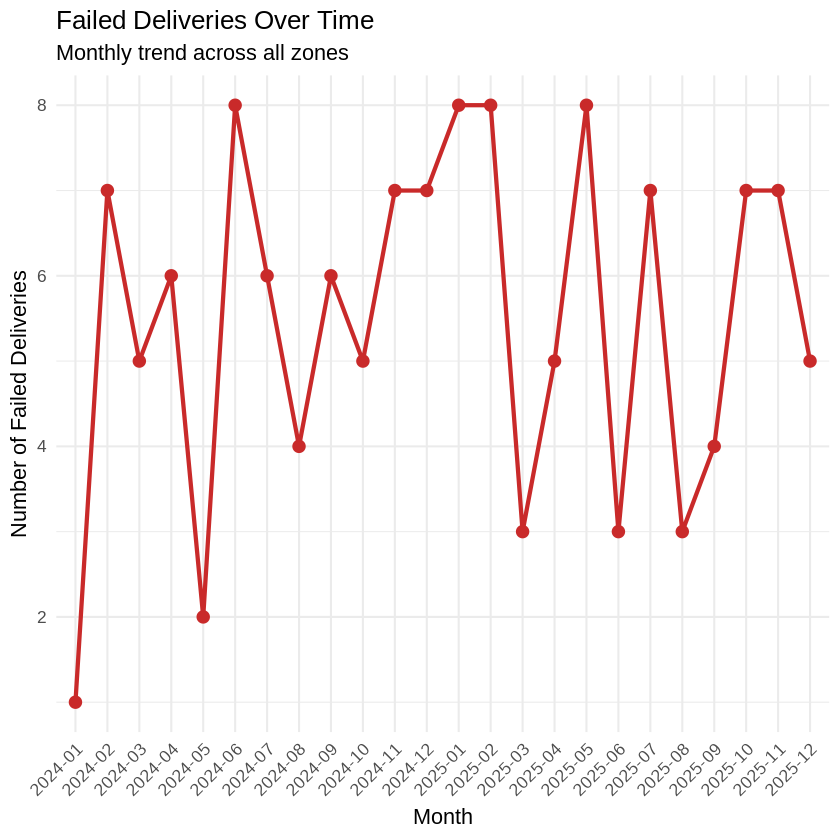

In [ ]:
# Extract month from order date
orders$month <- format(orders$order_created_at, "%Y-%m")

monthly_orders <- sqldf("
  SELECT
    orders.month,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN deliveries.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed
  FROM orders
  JOIN deliveries ON orders.order_id = deliveries.order_id
  GROUP BY orders.month
  ORDER BY orders.month
")

print(monthly_orders)

ggplot(monthly_orders, aes(x = month, y = failed, group = 1)) +
  geom_line(color = "#c92a2a", linewidth = 1.2) +
  geom_point(color = "#c92a2a", size = 3) +
  labs(
    title = "Failed Deliveries Over Time",
    subtitle = "Monthly trend across all zones",
    x = "Month", y = "Number of Failed Deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Step 5 — Visualisations

All charts are interpreted in business terms below each figure. Visualisations
are used to make patterns visible that are difficult to see in raw query output.

Chart 1: Failure rate by zone

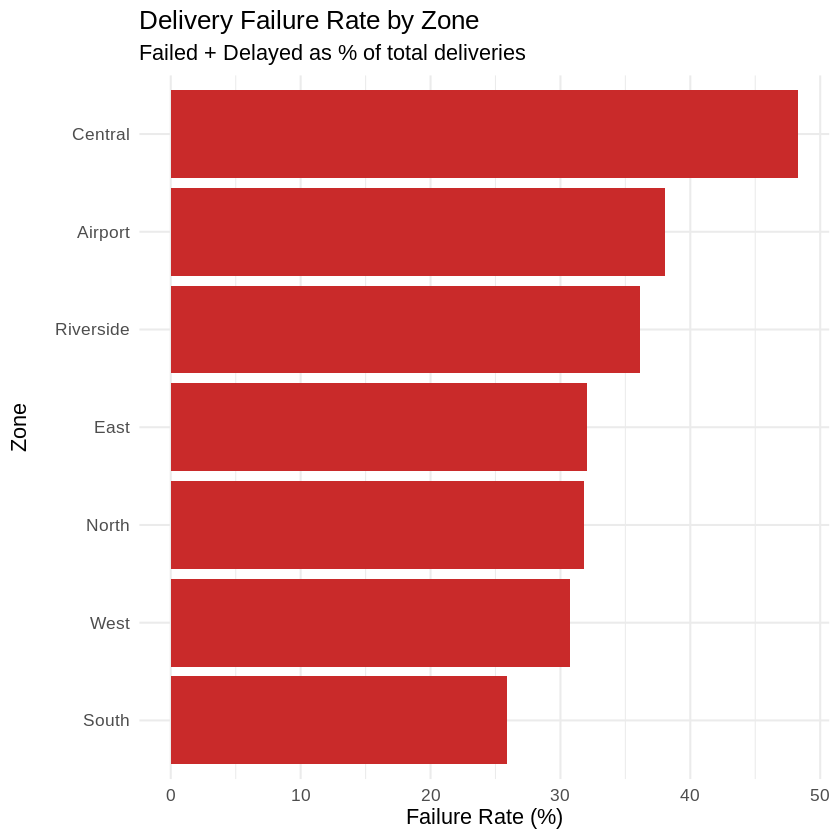

In [ ]:
ggplot(zone_failures, aes(x = reorder(pickup_zone, failure_rate_pct), y = failure_rate_pct)) +
  geom_col(fill = "#c92a2a") +
  coord_flip() +
  labs(
    title = "Delivery Failure Rate by Zone",
    subtitle = "Failed + Delayed as % of total deliveries",
    x = "Zone",
    y = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 13)

Chart 2: Margin by service type

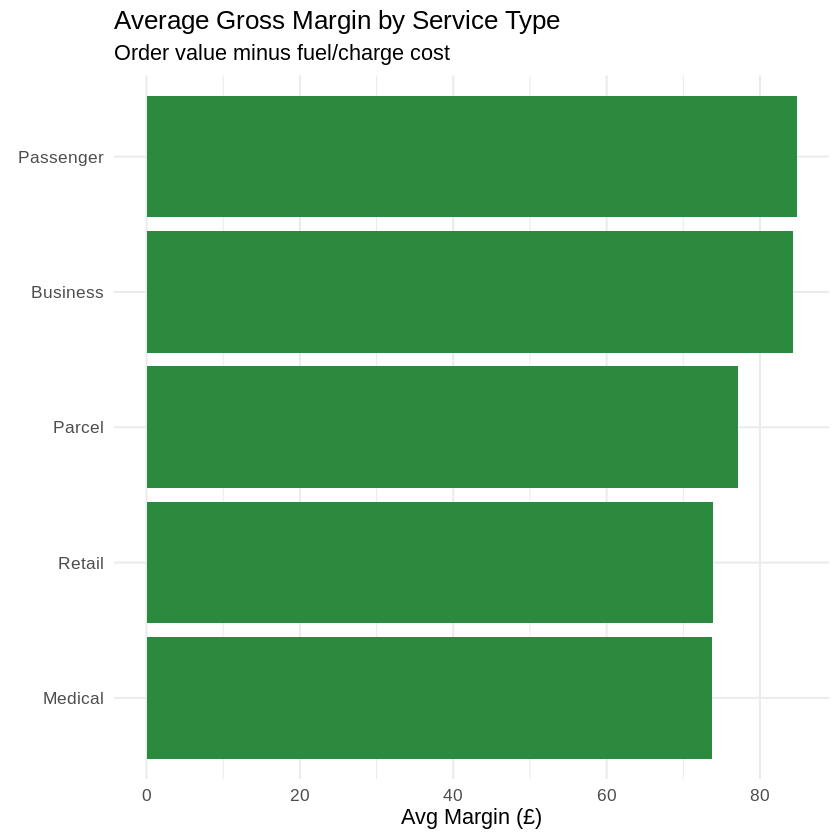

In [ ]:
ggplot(service_margin, aes(x = reorder(service_type, avg_margin), y = avg_margin,
                            fill = avg_margin > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("TRUE" = "#2b8a3e", "FALSE" = "#c92a2a")) +
  labs(
    title = "Average Gross Margin by Service Type",
    subtitle = "Order value minus fuel/charge cost",
    x = NULL,
    y = "Avg Margin (£)"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

Chart 3: Driver overrides vs customer rating

`geom_smooth()` using formula = 'y ~ x'


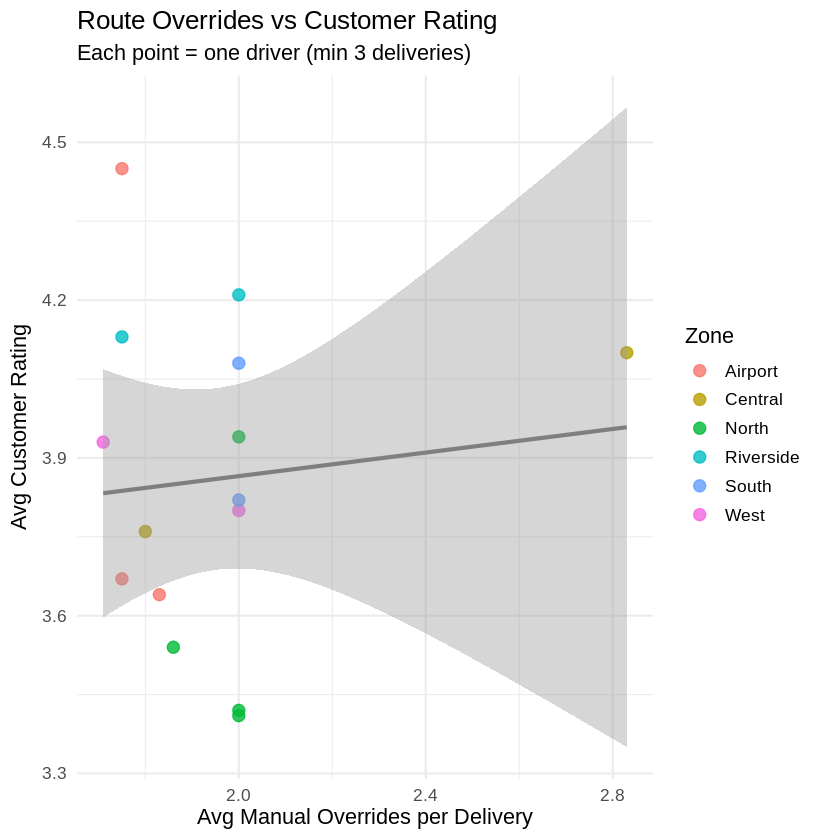

In [ ]:
ggplot(driver_overrides, aes(x = avg_overrides, y = avg_customer_rating, color = base_zone)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE, color = "grey50") +
  labs(
    title = "Route Overrides vs Customer Rating",
    subtitle = "Each point = one driver (min 3 deliveries)",
    x = "Avg Manual Overrides per Delivery",
    y = "Avg Customer Rating",
    color = "Zone"
  ) +
  theme_minimal(base_size = 13)